In [1]:
import platform
from fractions import Fraction
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

try:
    import scipy; SCIPY = scipy.__version__
except ImportError:
    SCIPY = 'not installed (not needed: all calculations here use NumPy/pandas)'

SEED = 42
pd.set_option('display.width', 140); pd.set_option('display.max_columns', 40)
plt.rcParams.update({'figure.dpi': 100, 'axes.grid': True, 'grid.alpha': .3})

BASEBALL_CSV = 'data.csv'
TAXI_CSV = '2024_Green_Taxi_Trip_Data_20260917.csv'
SAMPLE_CSV = 'taxi_sample.csv'
TS_FMT = '%m/%d/%Y %I:%M:%S %p'

print('Python', platform.python_version(), '| pandas', pd.__version__, '| NumPy', np.__version__,
      '| Matplotlib', matplotlib.__version__, '| SciPy', SCIPY)

Python 3.8.10 | pandas 2.0.3 | NumPy 1.24.4 | Matplotlib 3.7.5 | SciPy not installed (not needed: all calculations here use NumPy/pandas)


## Shared helper functions
Used by both parts: outlier rule (1.5 x IQR), descriptive statistics, histogram/ECDF plotting and the sampling experiment.

In [2]:
# Tukey's IQR rule for flagging *potential* outliers. Values are flagged, not
# deleted: whether they are errors or real extremes is a judgement made later.
def iqr_flags(x):
    # Q1 = 25th percentile, Q3 = 75th percentile. np.percentile interpolates
    # linearly between neighbouring sorted values when the rank is fractional.
    q1, q3 = np.percentile(x, [25, 75])            # linear interpolation (NumPy default)
    # IQR = q3 - q1 is the spread of the middle 50% of the data. The fences sit
    # 1.5 IQRs below Q1 and above Q3 (the classic box-plot whisker rule).
    lo, hi = q1 - 1.5*(q3-q1), q3 + 1.5*(q3-q1)
    # Return the quartiles and fences (for reporting) plus a boolean array that
    # is True where a value lies outside [lo, hi]. `|` is element-wise OR.
    return q1, q3, lo, hi, (x < lo) | (x > hi)

def describe(x, label):
    x = np.asarray(x, float)
    # The geometric mean uses log(x), which is undefined for zero/negative/NaN
    # values. This assert stops the code with a clear message instead of
    # silently returning NaN or -inf.
    assert np.isfinite(x).all() and (x > 0).all(), f'{label}: geometric mean needs finite, strictly positive values'
    # Percentiles 0, 25, 50, 75, 100 are min, Q1, median, Q3, max, in one call.
    mn, q1, med, q3, mx = np.percentile(x, [0, 25, 50, 75, 100])   # linear interpolation
    return pd.Series({'count': len(x), 'arithmetic mean': x.mean(), 'median': med,
                      # Geometric mean = (x1*x2*...*xn)^(1/n) = exp(mean(log x)).
                      # Working through logs avoids overflow from huge products.
                      # It is always <= the arithmetic mean and dampens big values.
                      'geometric mean': np.exp(np.log(x).mean()),
                      # ddof=1 divides by n-1 ("Bessel's correction"): the sample
                      # is used to estimate a bigger population's variance, and
                      # dividing by n would systematically underestimate it.
                      'sample variance (ddof=1)': x.var(ddof=1), 'sample SD (ddof=1)': x.std(ddof=1),
                      # The five-number-summary values computed above.
                      'min': mn, 'Q1': q1, 'Q3': q3, 'max': mx}, name=label)

def show_stats(x, label):
    st = describe(x, label).to_frame()
    display(st.style.format('{:.6f}', subset=pd.IndexSlice[st.index != 'count', :]).format('{:.0f}', subset=pd.IndexSlice[['count'], :]))

# Density histogram with equal-width bins that all start at a chosen point.
def hist_density(x, width, start):
    edges = np.round(np.arange(start, x.max() + width, width), 10)
    # np.histogram counts values per bin. Bins are half-open [a, b) except the
    # last one, which also includes its right edge.
    counts, edges = np.histogram(x, bins=edges)
    # Density = count / (n * bin width). Then bar height x width = share of the
    # data in that bin, so the bars' total AREA is exactly 1 (a proper density,
    # comparable across different bin widths and sample sizes).
    dens = counts / (len(x) * width)
    return dens, edges

# Empirical CDF: for each sorted value, the fraction of data at or below it.
def ecdf(x):
    # Sorted values on the x-axis; the i-th smallest value has i/n of the data
    # at or below it, so y runs 1/n, 2/n, ..., 1. (Ties simply stack.)
    xs = np.sort(x); return xs, np.arange(1, len(xs)+1) / len(xs)

def dens_ecdf_plot(x, width, start, name, unit, xlim, fname):
    dens, edges = hist_density(x, width, start)
    xs, ys = ecdf(x)
    fig, ax = plt.subplots(2, 1, figsize=(8, 7), sharex=True)
    ax[0].bar(edges[:-1], dens, width=width, align='edge', edgecolor='white', color='#3b6ea5')
    ax[0].set_ylabel('Density'); ax[0].set_title(f'{name} ({unit}) - normalized histogram (bin width {width:g}), n = {len(x):,}')
    ax[1].step(xs, ys, where='post', color='#b5533c')
    ax[1].set_ylabel('Cumulative probability'); ax[1].set_title(f'{name} ({unit}) - ECDF, n = {len(x):,}')
    ax[1].set_xlabel(f'{name} ({unit})'); ax[1].set_xlim(*xlim)
    fig.tight_layout(); plt.show()
    return dens, edges, xs, ys

# Verify the histogram and ECDF tell the same story (a self-check on the plots).
def hist_checks(name, dens, edges, xs, ys):
    widths = np.diff(edges)
    # Sum of bar areas; a correct density histogram gives exactly 1.
    area = (dens * widths).sum()
    # Cumulative sum of the bar areas = the probability accumulated up to each
    # bin's right edge, i.e. what the ECDF should equal at those points.
    cum_hist = np.cumsum(dens * widths)
    # Independent ECDF value at each right edge: searchsorted(side='left')
    # counts data strictly below the edge; dividing by n gives a proportion.
    # 'left' matches the [a, b) bin convention (a value on an edge belongs to
    # the NEXT bin), so the two calculations are comparable.
    ecdf_at_edges = np.searchsorted(xs, edges[1:], side='left') / len(xs)   # share of values strictly below each right edge (bins are [a, b))
    # Expect: area = 1.000000, ECDF max = 1.0, and a gap near 0 (tiny non-zero
    # values can appear only when the last bin includes its right edge).
    print(f'{name}: total histogram area = {area:.6f} | ECDF max = {ys[-1]:.1f} | max density = {dens.max():.2f}'
          f' | max |integrated hist - ECDF| at bin edges = {np.abs(cum_hist - ecdf_at_edges).max():.4f}')

# Simulation: draw many random samples of size n and record each sample's mean.
# This shows empirically how the sample mean behaves (Central Limit Theorem).
def sampling_experiment(x, sizes=(5, 30), reps=1000, seed=SEED):
    rng = np.random.default_rng(seed)
    out = {}
    for n in sizes:
        # A (reps x n) grid of random positions in x: each row is one sample.
        # Independent draws with replacement = i.i.d. sampling from the data,
        # treating the data itself as the population.
        idx = rng.integers(0, len(x), size=(reps, n))      # independent draws WITH replacement
        # x[idx] swaps positions for actual values (reps x n); the mean along
        # axis=1 collapses each row to that sample's mean -> 1,000 means.
        out[n] = x[idx].mean(axis=1)
    return out

# Compare the simulation to theory: Var(sample mean) = sigma^2 / n.
def summarize(x, means):
    # Population variance sigma^2 divides by n (ddof=0) because the dataset IS
    # the population we sample from here (unlike describe(), which treats data as a sample).
    pop_var0 = x.var(ddof=0)
    rows = []
    for n, m in means.items():
        # Unbiased centre: the average of the sample means should ~ population mean.
        rows.append({'n': n, 'mean of sample means': m.mean(), 'population mean': x.mean(),
                     # Observed variance of the means (ddof=1: they are a simulated
                     # sample) vs the theoretical value sigma^2/n.
                     'sample variance of means (ddof=1)': m.var(ddof=1), 'benchmark var0/n': pop_var0/n,
                     # Observed / theoretical: a ratio close to 1 confirms the theory.
                     'ratio': m.var(ddof=1)/(pop_var0/n),
                     # Same comparison as standard deviations (the "standard error").
                     'sample SD of means (ddof=1)': m.std(ddof=1), 'benchmark SD': np.sqrt(pop_var0/n)})
    return pd.DataFrame(rows).set_index('n')

def means_plot(x, res, name, unit):
    lo = min(m.min() for m in res.values()); hi = max(m.max() for m in res.values())
    bins = np.linspace(lo, hi, 41)
    fig, ax = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
    for a, (n, m) in zip(ax, res.items()):
        a.hist(m, bins=bins, density=True, color='#3b6ea5' if n == 5 else '#b5533c', edgecolor='white')
        a.axvline(x.mean(), color='k', ls='--', lw=1, label=f'population mean = {x.mean():.4g}')
        a.set_ylabel('Density'); a.set_title(f'{name}: distribution of 1,000 sample means, n = {n}'); a.legend()
    ax[-1].set_xlabel(f'sample mean of {name} ({unit})')
    fig.tight_layout(); plt.show()

# Lab 1

## Baseball Statistics

Use data.csv. It contains 155 annual aggregate records from 1871 to 2025 and 30 columns. Each row describes a year, not an individual player. Use BA (batting average, a unitless proportion) as the main variable. Year identifies the year; G is the reported game count. R and R/G contain identical values in this file and must not be treated as separate measures.

Use years through 2024 for the main analysis. The 2025 row has a lower game count and may be an incomplete-season snapshot. The supplied file does not establish its extraction date or original provenance; acknowledge that limitation rather than claiming historical accuracy. Give each retained year equal weight and do not interpret the mean of annual BA values as a pooled player batting average.

### Exploratory questions

**Baseball (unit of observation: one year; ~154 annual records, 1871-2024).**

1. *Distribution / comparison.* How does the distribution of annual BA differ before and after 1985 (modern era)? Needs Year and BA. The 1985 cut point is the start of the steroid era; the rows are years, so the answer describes annual league aggregates, not players.
2. *Association.* Across years, is BA related to strikeouts per game (SO) - i.e. did years with more strikeouts tend to have lower BA? Needs BA and SO; the rows are year-level, so any answer is about years, not players or causes.
3. *Comparison.* Are years in the 2020s (2020-2024) different in BA from the preceding decade? Needs Year and BA; only five recent rows, so the answer is descriptive.

Not answerable: anything about individual players, or pooled (player-weighted) batting averages - a mean of annual BA values is not a pooled average.

### Data loading and cleaning

In [3]:
bb_raw = pd.read_csv(BASEBALL_CSV, dtype=str, na_values=['--'], keep_default_na=True)
print('Baseball raw shape:', bb_raw.shape)
bb = bb_raw.apply(pd.to_numeric, errors='raise')
print(bb.dtypes.value_counts().to_string())
display(bb.head(3)); display(bb.tail(3))

Baseball raw shape: (155, 30)
float64    26
int64       4


,Year,Tms,#Bat,BatAge,R/G,G,PA,AB,R,H,1B,2B,3B,HR,RBI,SB,CS,BB,SO,BA,OBP,SLG,OPS,TB,GDP,HBP,SH,SF,IBB,BIP
0,2025,30,673,28.1,4.39,3072,37.63,33.65,4.39,8.26,5.41,1.60,0.13,1.12,4.21,0.72,0.21,3.18,8.25,0.245,0.316,0.401,0.716,13.49,0.65,0.39,0.12,0.27,0.12,24.55
1,2024,30,741,27.9,4.39,4858,37.56,33.69,4.39,8.20,5.34,1.60,0.14,1.12,4.19,0.74,0.20,3.07,8.48,0.243,0.312,0.399,0.711,13.45,0.66,0.42,0.09,0.26,0.10,24.35
2,2023,30,765,28.0,4.62,4860,37.88,33.83,4.62,8.40,5.35,1.69,0.15,1.21,4.43,0.72,0.18,3.25,8.61,0.248,0.320,0.414,0.734,14.01,0.71,0.43,0.09,0.25,0.10,24.26


,Year,Tms,#Bat,BatAge,R/G,G,PA,AB,R,H,1B,2B,3B,HR,RBI,SB,CS,BB,SO,BA,OBP,SLG,OPS,TB,GDP,HBP,SH,SF,IBB,BIP
152,1873,9,122,24.4,8.99,398,43.45,42.61,8.99,12.38,10.30,1.43,0.53,0.12,5.86,0.79,0.33,0.84,0.70,0.290,0.304,0.357,0.661,15.22,0.31,NaN,NaN,NaN,NaN,41.79
153,1872,11,143,23.7,9.26,366,43.52,42.80,9.26,12.20,10.11,1.59,0.40,0.10,5.83,0.73,0.37,0.72,0.72,0.285,0.297,0.348,0.645,14.89,0.27,NaN,NaN,NaN,NaN,41.98
154,1871,9,115,23.8,10.47,254,44.15,42.61,10.47,12.21,9.37,1.71,0.94,0.19,7.02,1.74,0.48,1.55,0.69,0.287,0.312,0.384,0.695,16.35,0.29,NaN,NaN,NaN,NaN,41.73


In [4]:
miss = pd.DataFrame({'missing': bb.isna().sum(), 'pct': (bb.isna().mean()*100).round(1)})
display(miss[miss.missing > 0])
print('Years unique:', bb.Year.is_unique, '| range:', bb.Year.min(), '-', bb.Year.max())
print('R identical to R/G in every row:', bool((bb['R'] == bb['R/G']).all()), '-> treated as ONE measure, neither is used further')
print('Missing BA values:', int(bb.BA.isna().sum()))
print('Games (G), last 4 rows:'); display(bb.sort_values('Year', ascending=False).head(4)[['Year','G','BA']])

,missing,pct
RBI,3,1.9
SB,10,6.5
CS,39,25.2
GDP,70,45.2
HBP,13,8.4
SH,23,14.8
SF,81,52.3
IBB,53,34.2


Years unique: True | range: 1871 - 2025
R identical to R/G in every row: True -> treated as ONE measure, neither is used further
Missing BA values: 0
Games (G), last 4 rows:


,Year,G,BA
0,2025,3072,0.245
1,2024,4858,0.243
2,2023,4860,0.248
3,2022,4860,0.243


Missingness is confined to some older-era columns (e.g. `RBI` 3 rows via `"--"`, `CS`, `SF`, `IBB`, ...). None of it touches `BA` or `Year`, so **no rows are dropped for missing values** and nothing is filled with zero.

**2025 row.** Its game count `G` is far below other recent seasons (about 3,072 vs about 4,860), so it is probably a partial-season snapshot. The file gives no extraction date or provenance, so this is an inference, not a verified fact. The main analysis uses **years through 2024**; each retained year has equal weight.

In [5]:
bb_log = [('raw rows', len(bb))]
ba_df = bb[bb.Year <= 2024].sort_values('Year').reset_index(drop=True)
bb_log.append(('keep Year <= 2024 (drop 2025 partial-season row)', len(ba_df)))
ba_df = ba_df[np.isfinite(ba_df.BA)]
bb_log.append(('BA finite', len(ba_df)))
display(pd.DataFrame(bb_log, columns=['step','rows']))
ba = ba_df.BA.to_numpy()

,step,rows
0,raw rows,155
1,keep Year <= 2024 (drop 2025 partial-season row),154
2,BA finite,154


**Outlier check for BA (1.5 x IQR rule).** A flagged value is not necessarily an error.

In [6]:
# Apply the IQR rule defined earlier: quartiles, fences, and a True/False flag per year.
q1, q3, lo, hi, flag = iqr_flags(ba)
print(f'BA: Q1={q1:.4f}  Q3={q3:.4f}  fences=[{lo:.4f}, {hi:.4f}]  flagged={flag.sum()}')
display(ba_df.loc[flag, ['Year','G','BA','HR','SO']])
ba_trim = ba[~flag]
display(pd.DataFrame({'all 154 years': [len(ba), ba.mean(), np.median(ba), ba.std(ddof=1)],
                      'flagged years removed (sensitivity only)': [len(ba_trim), ba_trim.mean(), np.median(ba_trim), ba_trim.std(ddof=1)]},
                     index=['n','mean','median','sd']).round(5))

BA: Q1=0.2540  Q3=0.2698  fences=[0.2304, 0.2934]  flagged=2


,Year,G,BA,HR,SO
23,1894,1596,0.309,0.39,2.09
24,1895,1594,0.296,0.31,2.27


,all 154 years,flagged years removed (sensitivity only)
n,154.00000,152.00000
mean,0.26205,0.26151
median,0.26000,0.26000
sd,0.01341,0.01264


Two years are flagged, both on the high side: **1894 (BA 0.309)** and **1895 (BA 0.296)**. They are both from the 1890s, a period when hitting was much higher than in later eras, so they look like real features of the early game rather than typing errors. **No years are removed.** The sensitivity table shows the effect of dropping them: the mean changes only slightly, the median hardly at all, so the BA conclusions do not depend on this decision.

### Descriptive statistics
Quartiles use linear interpolation (`np.percentile`, NumPy's default `linear` method). Variance and SD use `ddof=1`.

In [7]:
# Table of count, arithmetic/geometric mean, median, variance, SD, min, Q1, Q3, max
# for annual BA. Reminder: this is the average of 154 season averages with equal
# weight per year - not the league-wide batting average across all at-bats.
show_stats(ba, 'BA (unitless)')

,BA (unitless)
count,154
arithmetic mean,0.262045
median,0.260000
geometric mean,0.261712
sample variance (ddof=1),0.000180
sample SD (ddof=1),0.013409
min,0.237000
Q1,0.254000
Q3,0.269750
max,0.309000


**BA (unitless proportion, 154 years, equal weight per year).** The mean (0.2620), median (0.2600) and geometric mean (0.2617) are nearly identical, and the distribution is modestly right-skewed (skewness about 0.71; the mean sits only about 0.15 SD above the median). The sample SD is about 0.0134 (i.e. about 13 points of BA) and the variance about 1.8e-4 (unitless squared). The middle 50% of years lie between 0.2540 and 0.2698, and the range is 0.237 to 0.309. This is the average of annual league BA values, **not** a pooled player batting average.

**Units.** The variance has squared units (BA squared, still unitless), so it is hard to read directly; the standard deviation keeps the original units (BA points) and is the one to interpret.

**Median vs. mean.** The median depends only on rank order, so a single extreme year hardly moves it, whereas the mean shifts by (change)/n and the variance even more because deviations are squared. Here mean and median almost coincide, so this matters little for BA.

**Multiplicative interpretation.** BA is a strictly positive ratio in a narrow band (0.237-0.309), so the geometric mean nearly equals the arithmetic mean and the multiplicative view adds little.

### Density and cumulative probability
Histogram bin width: **0.005**, chosen because it gives about 15 bins across the observed range (0.237-0.309), enough to show the shape without leaving most bins nearly empty for only 154 years. Density = count / (n x bin width), so the bar *areas* sum to 1. The histogram and ECDF panels share the same horizontal range.

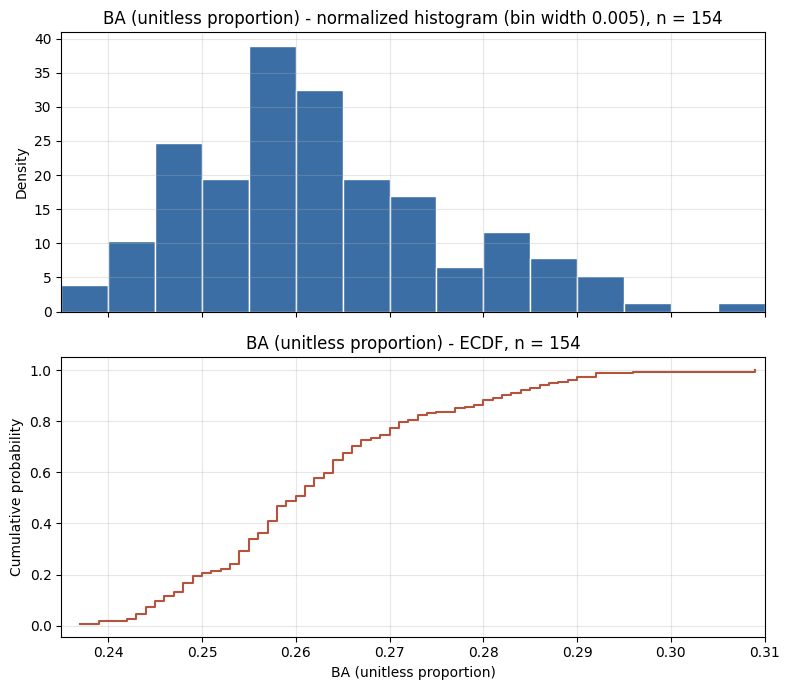

BA: total histogram area = 1.000000 | ECDF max = 1.0 | max density = 38.96 | max |integrated hist - ECDF| at bin edges = 0.0000


- **Read from the ECDF:** P(annual BA <= 0.250) = **0.208** (32 of 154 years); median (50th percentile) = 0.2600; 90th percentile = 0.2820.

In [8]:
ba_start = np.floor(ba.min()/0.005)*0.005
dens_b, edges_b, xs_b, ys_b = dens_ecdf_plot(ba, 0.005, ba_start, 'BA', 'unitless proportion',
                                            (ba_start, np.ceil(ba.max()/0.005)*0.005), 'ba')
# Self-check: expect area 1, ECDF ending at 1, and near-zero disagreement between
# the integrated histogram and the ECDF.
hist_checks('BA', dens_b, edges_b, xs_b, ys_b)

ba_thr = 0.250
# (ba <= thr) is a True/False array; its mean is the fraction of True = the
# empirical probability that a randomly chosen year has BA <= 0.250 - exactly
# the value the ECDF curve reads at x = 0.250.
p_ba = (ba <= ba_thr).mean()
# Report the answer with the raw counts behind it, plus the median (50th
# percentile) and 90th percentile, which are also readable from the ECDF.
display(Markdown(f'- **Read from the ECDF:** P(annual BA <= {ba_thr:.3f}) = **{p_ba:.3f}** ({(ba<=ba_thr).sum()} of {len(ba)} years); median (50th percentile) = {np.percentile(ba,50):.4f}; 90th percentile = {np.percentile(ba,90):.4f}.'))

### Sampling variability experiment
The cleaned BA values are treated as an empirical population. A NumPy generator seeded with 42 draws 1,000 samples of size 5 and then 1,000 of size 30, with replacement. Benchmark: population variance with `ddof=0` divided by n (the variance of the mean of n independent draws with replacement from this empirical population). The A3 statistics used `ddof=1` because they estimate a variance from a sample; here the retained values *are* the population, so `ddof=0` is exact.

BA (population var ddof=0: 1.786e-04 vs ddof=1: 1.798e-04)


,mean of sample means,population mean,sample variance of means (ddof=1),benchmark var0/n,ratio,sample SD of means (ddof=1),benchmark SD
n,,,,,,,
5,0.261982,0.262045,3.82001e-05,3.57256e-05,1.06926,0.00618062,0.00597709
30,0.262013,0.262045,6.10429e-06,5.95426e-06,1.0252,0.00247069,0.00244014


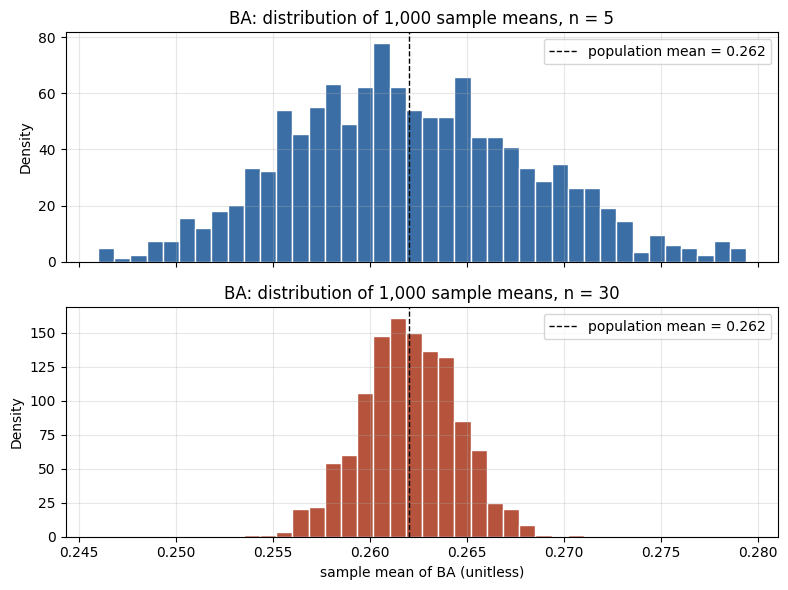

In [9]:
# 1,000 random samples of size 5 and 1,000 of size 30 (with replacement) from
# the annual BA values; res_ba holds the mean of each sample.
res_ba = sampling_experiment(ba)
pd.options.display.float_format = '{:.6g}'.format
# Show the population variance under both conventions to make the point that
# ddof matters: ddof=0 (population, used for theory here) vs ddof=1 (sample).
# Then the table: does the variance of sample means match sigma^2/n?
print('BA (population var ddof=0: %.3e vs ddof=1: %.3e)' % (ba.var(ddof=0), ba.var(ddof=1))); display(summarize(ba, res_ba))
# Histograms of the sample means: they should be centred on the population mean,
# and narrower/more bell-shaped for n=30 than n=5 (the Central Limit Theorem).
means_plot(ba, res_ba, 'BA', 'unitless')

**Larger samples give less variable means.** The variance of the sample means falls by roughly a factor of 6 going from n = 5 to n = 30 (3.82e-5 -> 6.10e-6), and the SD by a factor of about 2.5 (0.00618 -> 0.00247), close to the sqrt(6) ~ 2.4 expected from the 1/n rule.

**Agreement with the benchmark.** The simulated variances are close to (population variance with ddof=0) / n, with ratios of 1.07 (n = 5) and 1.03 (n = 30). The simulated means sit next to the population mean. The match is approximate, not exact, because 1,000 Monte Carlo replications carry random error.

**Why ddof=0 for the benchmark.** The retained values *are* the population here, and the exact variance of one uniformly drawn value is the population variance (divide by N, ddof=0). The Task 3 variance used ddof=1 because it estimates a variance from a sample. The two differ by the factor N/(N-1), tiny for N = 154.

### Bayes' theorem
Records: the 154 retained years (1871-2024), one selected uniformly at random. **A** = Year >= 1950; **B** = BA >= 0.260.

In [10]:
# Define two events over the 154 years, as boolean arrays (True = event happened):
# A = "the year is 1950 or later";  B = "annual BA is at least 0.260".
A = (ba_df.Year >= 1950).to_numpy(); B = (ba_df.BA >= 0.260).to_numpy()
N = len(ba_df)
tab = pd.crosstab(pd.Series(np.where(A, 'A: Year >= 1950', 'not A: Year < 1950'), name=''),
                  pd.Series(np.where(B, 'B: BA >= 0.260', 'not B: BA < 0.260'), name=''),
                  margins=True, margins_name='Total')
display(tab)

# The four cells of the table. & is element-wise AND and ~ is NOT; summing a
# boolean array counts the True values. int() gives plain Python integers, which Fraction needs.
n_AB, n_AnB = int((A & B).sum()), int((A & ~B).sum())
n_nAB, n_nAnB = int((~A & B).sum()), int((~A & ~B).sum())
# Marginals: years in A, years not in A, years in B (each is a sum of cells).
nA, nnA, nB = n_AB + n_AnB, n_nAB + n_nAnB, n_AB + n_nAB
# Guard rails: the pieces must add back to N, and no denominator we divide by
# below (nA, nnA, nB) may be zero (P(B|A) would be undefined).
assert nA + nnA == N and nB > 0 and nA > 0 and nnA > 0

# Prior probabilities as EXACT fractions: P(A) = |A|/N and P(not A) = |not A|/N.
P_A, P_nA = Fraction(nA, N), Fraction(nnA, N)
# Conditional probabilities ("likelihoods"): among A-years, the share with B;
# among not-A years, the share with B. The denominator changes to the group size.
P_B_A, P_B_nA = Fraction(n_AB, nA), Fraction(n_nAB, nnA)
print(f'P(A)       = {nA}/{N} = {float(P_A):.6f}')
print(f'P(not A)   = {nnA}/{N} = {float(P_nA):.6f}')
print(f'P(B | A)   = {n_AB}/{nA} = {float(P_B_A):.6f}')
print(f'P(B | not A) = {n_nAB}/{nnA} = {float(P_B_nA):.6f}')

# Law of total probability: A and not-A split all years into two non-overlapping
# groups, so P(B) is the weighted average of P(B|group) with weights P(group).
P_B = P_B_A*P_A + P_B_nA*P_nA
print(f'\nP(B) = P(B|A)P(A) + P(B|not A)P(not A) = {float(P_B_A):.6f} x {float(P_A):.6f} + {float(P_B_nA):.6f} x {float(P_nA):.6f} = {float(P_B):.6f}   (= {nB}/{N})')
# Exact check (possible only because we used Fractions): the formula must equal nB/N with no rounding error.
assert P_B == Fraction(nB, N)
# Bayes' rule reverses the conditioning: from P(B|A) (how likely high BA is in
# modern years) to P(A|B) (how likely a high-BA year is a modern one).
post = P_B_A*P_A / P_B
print(f'\nBayes: P(A | B) = P(B|A)P(A) / P(B) = ({float(P_B_A):.6f} x {float(P_A):.6f}) / {float(P_B):.6f} = {float(post):.6f}')
# Cross-check by definition: among the B-years only, the fraction that are also A.
direct = Fraction(n_AB, nB)
print(f'Direct: P(A | B) = #(A and B) / #B = {n_AB}/{nB} = {float(direct):.6f}')
# The two routes must agree EXACTLY (fractions have no rounding); then confirm in the output.
assert post == direct; print('Both methods agree exactly.')

,B: BA >= 0.260,not B: BA < 0.260,Total
,,,
A: Year >= 1950,28,47,75
not A: Year < 1950,51,28,79
Total,79,75,154


P(A)       = 75/154 = 0.487013
P(not A)   = 79/154 = 0.512987
P(B | A)   = 28/75 = 0.373333
P(B | not A) = 51/79 = 0.645570

P(B) = P(B|A)P(A) + P(B|not A)P(not A) = 0.373333 x 0.487013 + 0.645570 x 0.512987 = 0.512987   (= 79/154)

Bayes: P(A | B) = P(B|A)P(A) / P(B) = (0.373333 x 0.487013) / 0.512987 = 0.354430
Direct: P(A | B) = #(A and B) / #B = 28/79 = 0.354430
Both methods agree exactly.


**Interpretation.** If a year is chosen uniformly at random from the 154 years and its BA is at least 0.260, the probability that it is from 1950 or later is P(A | B) = 28/79 = **0.354**, so it is more likely (0.646) to be a pre-1950 year.

**P(A | B) is not P(B | A).** P(B | A) = 28/75 = 0.373 answers "among years since 1950, what share had BA >= 0.260?", whereas P(A | B) answers "among years with BA >= 0.260, what share are since 1950?". They have different conditioning sets and denominators (75 vs. 79 here), and Bayes' theorem is what converts one into the other using P(A) and P(B).

**Simple classification.** Given only that a year's BA is at least 0.260, the better guess for "before 1950 or not" is *before 1950*, and given BA below 0.260 the better guess is 1950 or later (47/75 = 0.627). This describes these 154 years only: it is an in-sample summary, not a measured predictive accuracy on new data, and it makes no causal claim about why BA differs across eras. Years are also not independent draws (see reflection).

## NYC 2024 Green Taxi trips

Use the official 2024 Green Taxi Trip Data dataset. Each row is a trip. Download its CSV using Export on the dataset page. Preserve the downloaded file and record the dataset title, URL, and download date.

**Source record**

- Dataset title: *2024 Green Taxi Trip Data* (NYC Open Data, NYC TLC)
- URL: https://data.cityofnewyork.us/Transportation/2024-Green-Taxi-Trip-Data/52n8-nrhw
- Dataset last updated on the portal: August 20, 2026
- Downloaded (Export, CSV): **September 17, 2026**, preserved unmodified as `2024_Green_Taxi_Trip_Data_20260917.csv`

Load the CSV, retain trips with pickup dates in 2024, then randomly select 10,000 rows without replacement using random_state=42. Save this raw sample as taxi_sample.csv before cleaning. Do not substitute the first 10,000 rows for a random sample. Use fare_amount (US dollars) as the main variable; it is distinct from total_amount.

### Asking good questions

**NYC taxi (unit of observation: one green-taxi trip; random sample of 10,000 trips in 2024).**

1. *Distribution.* What does the distribution of fare_amount look like (center, spread, skew, share below a threshold)? Needs fare_amount; a random sample of 2024 trips supports statements about 2024 green-taxi trips overall.
2. *Association.* How does fare_amount vary with trip duration in minutes? This needs fare_amount plus the pickup and drop-off timestamps (lpep_pickup_datetime, lpep_dropoff_datetime), from which duration is derived. Each trip row has all three, so the sample can describe the relationship across 2024 trips. It shows association only. The meter charges for both distance and time, so duration and distance are entangled, and you can't say duration "causes" the fare.
3. *Comparison.* Does fare_amount differ between street-hail and dispatch trips (trip_type)? Needs trip_type; note some rows have a missing trip_type.

Not answerable: long-term fare trends (single year of data) or fares of yellow/for-hire vehicles.

### Data loading and cleaning

In [11]:
taxi_all = pd.read_csv(TAXI_CSV, dtype=str)
print('Taxi file shape:', taxi_all.shape)
display(taxi_all.dtypes.to_frame('dtype (as loaded)').T)
display(taxi_all.head(3))

Taxi file shape: (660218, 20)


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
dtype (as loaded),object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object,object


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge
0,2,01/01/2024 12:46:55 AM,01/01/2024 12:58:25 AM,N,1,236,239,1,1.98,12.8,1,0.5,3.61,0,NaN,1,21.66,1,1,2.75
1,2,01/01/2024 12:31:42 AM,01/01/2024 12:52:34 AM,N,1,65,170,5,6.54,30.3,1,0.5,7.11,0,NaN,1,42.66,1,1,2.75
2,2,01/01/2024 12:30:21 AM,01/01/2024 12:49:23 AM,N,1,74,262,1,3.08,19.8,1,0.5,3,0,NaN,1,28.05,1,1,2.75


In [12]:
pickup_all = pd.to_datetime(taxi_all['lpep_pickup_datetime'], format=TS_FMT, errors='coerce')
print('Unparseable pickup timestamps in full file:', int(pickup_all.isna().sum()))
print('Pickup year counts in full file:'); print(pickup_all.dt.year.value_counts().sort_index().to_string())

taxi_2024 = taxi_all[pickup_all.dt.year == 2024]
sample_raw = taxi_2024.sample(n=10_000, replace=False, random_state=SEED)
sample_raw.to_csv(SAMPLE_CSV, index=False)

sampling_log = [('rows in downloaded file', len(taxi_all)),
                ('pickup date in 2024', len(taxi_2024)),
                ('random sample, n=10,000, replace=False, random_state=42', len(sample_raw))]
display(pd.DataFrame(sampling_log, columns=['step','rows']))

Unparseable pickup timestamps in full file: 0
Pickup year counts in full file:
lpep_pickup_datetime
2008         4
2009         3
2023         2
2024    660198
2025        11


,step,rows
0,rows in downloaded file,660218
1,pickup date in 2024,660198
2,"random sample, n=10,000, replace=False, random...",10000


The sample is drawn once and never re-drawn: rows removed in cleaning are **not** replaced, so the final size is smaller than 10,000. Cleaning always works on a copy of the raw sample.

In [13]:
s = pd.read_csv(SAMPLE_CSV, dtype=str)
assert s.equals(sample_raw.reset_index(drop=True))
log = [('raw sample', len(s))]

num_cols = ['passenger_count','trip_distance','fare_amount','extra','mta_tax','tip_amount','tolls_amount',
            'improvement_surcharge','total_amount','congestion_surcharge']
bad_before = {}
for c in num_cols:
    cleaned = s[c].str.replace(',', '', regex=False)
    conv = pd.to_numeric(cleaned, errors='coerce')
    bad_before[c] = int((conv.isna() & s[c].notna()).sum())
    s[c] = conv
print('Values that could not be converted (non-missing but non-numeric):', {k:v for k,v in bad_before.items() if v})

s['pickup']  = pd.to_datetime(s['lpep_pickup_datetime'],  format=TS_FMT, errors='coerce')
s['dropoff'] = pd.to_datetime(s['lpep_dropoff_datetime'], format=TS_FMT, errors='coerce')
s['minutes'] = (s['dropoff'] - s['pickup']).dt.total_seconds() / 60

print('\nMissing values by column:'); display(s.isna().sum()[lambda x: x>0].to_frame('missing'))
print('Unparseable timestamps  pickup:', int(s.pickup.isna().sum()), ' dropoff:', int(s.dropoff.isna().sum()))

Values that could not be converted (non-missing but non-numeric): {}

Missing values by column:


,missing
store_and_fwd_flag,365
RatecodeID,365
passenger_count,365
ehail_fee,10000
payment_type,365
trip_type,366
congestion_surcharge,365


Unparseable timestamps  pickup: 0  dropoff: 0


In [14]:
checks = pd.Series({
    'nonpositive duration (dropoff <= pickup)': int((s.minutes <= 0).sum()),
    'duration > 5 hours':                       int((s.minutes > 300).sum()),
    'fare_amount == 0':                         int((s.fare_amount == 0).sum()),
    'fare_amount < 0':                          int((s.fare_amount < 0).sum()),
    'fare_amount missing / non-finite':         int((~np.isfinite(s.fare_amount)).sum()),
    'trip_distance == 0':                       int((s.trip_distance == 0).sum()),
    'trip_distance > 50 miles':                 int((s.trip_distance > 50).sum()),
    'total_amount < fare_amount':               int((s.total_amount < s.fare_amount).sum()),
    'fully identical rows (all columns)':       int(s.drop(columns=['minutes']).duplicated(keep=False).sum()),
})
display(checks.to_frame('rows'))
print('Extreme fares:'); display(s.nlargest(5,'fare_amount')[['pickup','minutes','trip_distance','fare_amount','total_amount','payment_type']])
print('Non-positive fares:'); display(s[s.fare_amount<=0][['minutes','trip_distance','fare_amount','total_amount','payment_type']].describe().round(2))
print('Payment type of non-positive fares:'); print(s[s.fare_amount<=0].payment_type.value_counts(dropna=False).to_string())

,rows
nonpositive duration (dropoff <= pickup),10
duration > 5 hours,40
fare_amount == 0,12
fare_amount < 0,29
fare_amount missing / non-finite,0
trip_distance == 0,552
trip_distance > 50 miles,7
total_amount < fare_amount,30
fully identical rows (all columns),0


Extreme fares:


,pickup,minutes,trip_distance,fare_amount,total_amount,payment_type
2405,2024-08-30 12:14:33,566,45.17,450.3,451.8,2
5607,2024-12-02 16:22:19,0.0666667,0.05,300,301,2
8524,2024-12-12 15:23:25,0.0833333,0.03,300,301,2
8901,2024-06-28 16:36:55,0.0666667,0,300,301,2
1870,2024-02-20 09:03:55,307.9,27.78,251.5,253,2


Non-positive fares:


,minutes,trip_distance,fare_amount,total_amount
count,41,41,41,41
mean,3.83,0.34,-7.46,-9.16
std,13.73,1.2,14.77,15.12
min,0.07,0,-64.6,-68.6
25%,0.33,0,-3.7,-7.7
50%,0.82,0,-3,-4.5
75%,2.23,0.1,0,0
max,88.5,7.5,0,1.5


Payment type of non-positive fares:
payment_type
3    21
4    12
2     5
1     3


**Decisions (based on the counts above).**

- **Timestamps:** all pickup/dropoff values parse. 20 rows of the full file have pickup dates outside 2024 (2008, 2009, 2023, 2025); these were excluded *before* sampling, as the lab requires.
- **Non-positive duration (10 rows):** dropoff equals pickup exactly (none is negative), which is impossible for a completed trip, so I treat these as invalid timestamp records and **exclude** them. All 10 also have zero distance.
- **Zero or negative fares (12 zero, 29 negative):** the negative fares are almost all payment types 3 (no charge) and 4 (dispute), i.e. voids/adjustments rather than fares for a ride. The lab's main analysis keeps only **strictly positive fares**, so all 41 are **excluded**. Consequence: the results describe positive-fare trips, not free, voided or disputed trips.
- **Identical rows:** none in this sample. If there were any, identical rows would still not prove duplicate trips (there is no trip ID), so I would keep and flag them rather than delete them automatically.
- **Unusual distances and durations:** 552 trips have zero distance, 7 exceed 50 miles, 40 last more than 5 hours. The fare analysis does not use distance or duration, and a valid long or odd trip is still a real fare, so these are **retained** but noted (they matter if you later model fare against distance).
- **Missing values:** `ehail_fee` is empty for every trip and 365 trips lack `RatecodeID`, `payment_type`, etc. None of this touches `fare_amount`, so no rows are dropped for it. `total_amount` is not used in the analysis.

In [15]:
clean = s.copy()

clean = clean[clean.pickup.notna() & clean.dropoff.notna()];           log.append(('valid pickup & dropoff timestamps', len(clean)))
clean = clean[clean.minutes > 0];                                       log.append(('trip duration > 0', len(clean)))
clean = clean[np.isfinite(clean.fare_amount) & (clean.fare_amount > 0)]; log.append(('finite, strictly positive fare_amount', len(clean)))

display(pd.DataFrame(log, columns=['step','rows remaining']).assign(removed=lambda d: -d['rows remaining'].diff().fillna(0).astype(int)))
fare = clean.fare_amount.to_numpy()
print('Final taxi sample size (fare analysis):', len(fare))
print('Identical-row duplicates remaining in cleaned data:', int(clean.drop(columns=['minutes']).duplicated().sum()), '(retained: see note)')

,step,rows remaining,removed
0,raw sample,10000,0
1,valid pickup & dropoff timestamps,10000,0
2,trip duration > 0,9990,10
3,"finite, strictly positive fare_amount",9949,41


Final taxi sample size (fare analysis): 9949
Identical-row duplicates remaining in cleaned data: 0 (retained: see note)


**Final sample size: 9,949** = 10,000 - 10 (non-positive duration) - 41 (non-positive fare). Removed rows were **not** replaced by resampling, so this is a random sample of 10,000 that was then filtered (about 0.5% removed). Conclusions apply to 2024 green-taxi trips with valid timestamps and a positive metered fare.

**Outlier check for fare_amount (1.5 x IQR rule).**

In [16]:
# Same IQR rule as for BA. Fares are right-skewed, so expect many high flags.
q1f, q3f, lof, hif, flagf = iqr_flags(fare)
# Report quartiles, fences, and how many fares fall outside (count, percent, and
# which side). A negative lower fence means no low-side flags are possible.
print(f'fare_amount: Q1=${q1f:.2f}  Q3=${q3f:.2f}  fences=[${lof:.2f}, ${hif:.2f}]  flagged={flagf.sum()} ({flagf.mean()*100:.1f}%)  low-side={int((fare<lof).sum())}  high-side={int((fare>hif).sum())}')
fl = clean[flagf]
display(fl.nlargest(8,'fare_amount')[['minutes','trip_distance','fare_amount','total_amount','RatecodeID']])
# If flagged trips are much longer/farther than typical, they're real long trips
# (keep them), not errors. Medians are used since they resist outliers. The % placeholders are filled by the tuple below.
print('Flagged trips: median distance %.1f mi, median duration %.0f min (vs. all: %.1f mi, %.0f min)' %
      (fl.trip_distance.median(), fl.minutes.median(), clean.trip_distance.median(), clean.minutes.median()))

trim = fare[~flagf]
# How much do n, mean, median and SD change without the flagged fares? Large
# changes in the mean/SD but small in the median show the outliers' influence.
sens = pd.DataFrame({'all positive fares': [len(fare), fare.mean(), np.median(fare), fare.std(ddof=1)],
                     'IQR-flagged removed (sensitivity only)': [len(trim), trim.mean(), np.median(trim), trim.std(ddof=1)]},
                    index=['n','mean','median','sd']).round(3)
display(sens)

fare_amount: Q1=$10.00  Q3=$21.20  fences=[$-6.80, $38.00]  flagged=743 (7.5%)  low-side=0  high-side=743


,minutes,trip_distance,fare_amount,total_amount,RatecodeID
2405,566,45.17,450.3,451.8,1
5607,0.0666667,0.05,300,301,5
8524,0.0833333,0.03,300,301,5
8901,0.0666667,0,300,301,5
1870,307.9,27.78,251.5,253,1
2394,76.5,37.85,231.2,239.64,4
993,52.0667,36.3,224.9,227.4,4
5639,53.9167,36.41,223.5,271.2,4


Flagged trips: median distance 9.5 mi, median duration 36 min (vs. all: 1.9 mi, 12 min)


,all positive fares,IQR-flagged removed (sensitivity only)
n,9949,9206
mean,18.464,15.042
median,14.2,13.5
sd,16.793,7.48


All **743 flagged fares (7.5%) are on the high side**; the low fence is negative, so nothing can be flagged low. Flagged trips are typically long (median about 9.5 miles and 36 minutes versus 1.9 miles and 12 minutes overall), so most high fares are what a long metered trip should cost, not errors. A few look suspect (e.g. $300 fares for trips of a few seconds under negotiated rate code 5), but I cannot verify them as mistakes. **I do not remove any.** The sensitivity table shows what removal would do: the mean drops from about $18.46 to $15.04 and the SD from about $16.79 to $7.48, while the median moves only from $14.20 to $13.50. Removing them would therefore describe a different (short-trip) population, and the mean and SD are affected far more than the median.

### Descriptive statistics
Uses exactly the retained observations from the cleaning step above (the cleaned positive-fare trips). Quartiles use linear interpolation (`np.percentile`, NumPy's default `linear` method). Variance and SD use `ddof=1`.

In [17]:
# Count, arithmetic/geometric mean, median, variance, SD, min, Q1, Q3, max in
# dollars. Expect mean > median (right skew) and geometric mean < arithmetic mean.
show_stats(fare, 'fare_amount (USD)')

,fare_amount (USD)
count,9949
arithmetic mean,18.464049
median,14.200000
geometric mean,14.839771
sample variance (ddof=1),282.002830
sample SD (ddof=1),16.792940
min,0.700000
Q1,10.000000
Q3,21.200000
max,450.300000


**fare_amount (US dollars, 9,949 trips).** The mean ($18.46) is well above the median ($14.20), and the geometric mean ($14.84) lies in between, which signals a strongly right-skewed distribution (skewness about 6.4) with a long tail of expensive trips (maximum $450.30). The SD is $16.79, and the variance is 282.00 **USD squared**. Half of the trips cost between $10.00 and $21.20.

**Units.** The variance is in USD squared; the standard deviation keeps the original units (dollars) and is the one to interpret.

**Median vs. mean.** The median depends only on the rank order of the observations, so changing the largest value (say from $450 to $4,500) leaves it unchanged, whereas the mean shifts by (change)/n and the variance is affected even more because deviations are squared. That is why, for the skewed fares, the median is the better "typical fare".

**Multiplicative interpretation.** It is useful for fares: they are strictly positive, right-skewed, and scale roughly proportionally with distance and time, so the geometric mean ($14.84) is a "typical multiplicative level" that is less pulled by the tail than the mean.

### Density and cumulative probability
Histogram bin width: **$2** (bins start at 0), chosen because with about 10,000 trips it resolves the mode and the right skew while keeping bin counts large enough to be smooth. Density = count / (n x bin width), so the bar *areas* sum to 1. The histogram and ECDF panels share the same horizontal range ($0-$100).

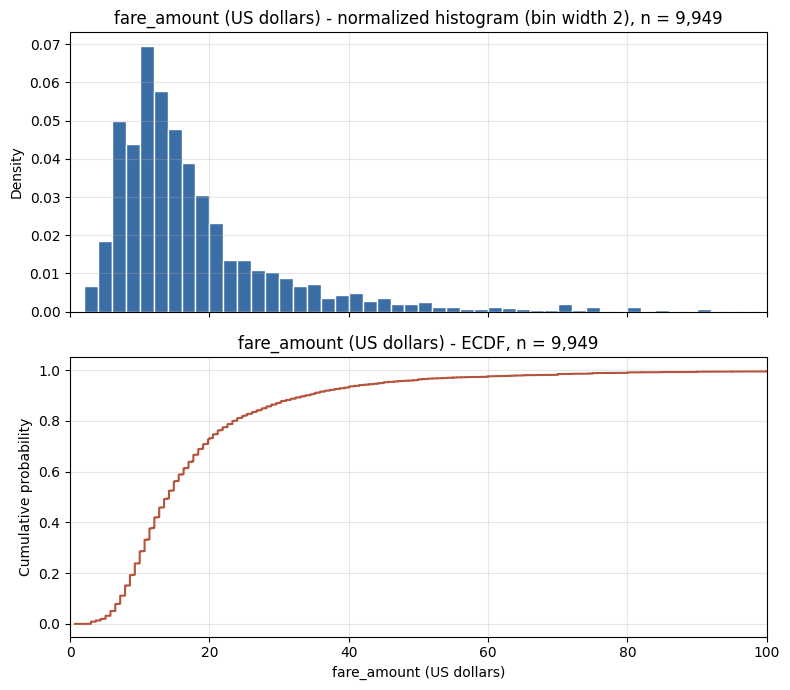

43 of 9,949 fares exceed $100 and lie beyond the plotted range (x-axis is clipped at $100 for readability; all values are used in every calculation).
fare_amount: total histogram area = 1.000000 | ECDF max = 1.0 | max density = 0.07 | max |integrated hist - ECDF| at bin edges = 0.0000


- **Read from the ECDF:** P(fare <= $20) = **0.732** (7,278 of 9,949 trips); median = $14.20; 90th percentile = $33.80.

In [18]:
dens_f, edges_f, xs_f, ys_f = dens_ecdf_plot(fare, 2.0, 0.0, 'fare_amount', 'US dollars', (0, 100), 'fare')
print(f'{(fare > 100).sum()} of {len(fare):,} fares exceed $100 and lie beyond the plotted range (x-axis is clipped at $100 for readability; all values are used in every calculation).')
# Self-check: area = 1, ECDF ends at 1, histogram and ECDF agree at bin edges.
hist_checks('fare_amount', dens_f, edges_f, xs_f, ys_f)

fare_thr = 20.0
# Fraction of trips with fare <= $20 = the ECDF's height at x = 20.
p_fare = (fare <= fare_thr).mean()
# Report probability with counts, median (50th pct) and 90th pct as read from the ECDF.
display(Markdown(f'- **Read from the ECDF:** P(fare <= ${fare_thr:.0f}) = **{p_fare:.3f}** ({(fare<=fare_thr).sum():,} of {len(fare):,} trips); median = ${np.percentile(fare,50):.2f}; 90th percentile = ${np.percentile(fare,90):.2f}.'))

**Checks.** The bar areas sum to 1.000000 and the ECDF reaches 1. Density is *not* a probability: here the bars are short (at most about 0.07 per dollar) because the $2 bins spread the probability over a wide range, but height x width summed over bins is 1. To get a cumulative probability from the histogram you add (bar height x bin width), not heights. At the bin edges the integrated histogram equals the ECDF exactly; *between* edges they need not agree, because the histogram assumes a uniform spread inside each bin.

**Reading the ECDF.** P(fare <= $20) = 0.732, i.e. about 73% of trips cost $20 or less; the median is $14.20 and the 90th percentile is $33.80.

**Histogram vs. ECDF.** The histogram shows shape: a mode around $10-$12 and a long right tail (43 fares above $100, cut off from the plot for readability but included in all calculations). The ECDF is easier for reading proportions below a threshold and percentiles, and shows every observation without a bin-width choice, but modes and skew are harder to see in it.

### Sampling variability experiment
The cleaned fare values are treated as an empirical population. A NumPy generator seeded with 42 draws 1,000 samples of size 5 and then 1,000 of size 30, with replacement. Benchmark: population variance with `ddof=0` divided by n (the variance of the mean of n independent draws with replacement from this empirical population). The B3 statistics used `ddof=1` because they estimate a variance from a sample; here the retained values *are* the population, so `ddof=0` is exact.

fare_amount (population var ddof=0: 281.974 vs ddof=1: 282.003)


,mean of sample means,population mean,sample variance of means (ddof=1),benchmark var0/n,ratio,sample SD of means (ddof=1),benchmark SD
n,,,,,,,
5,18.306,18.464,54.8096,56.3949,0.971889,7.40335,7.50965
30,18.3931,18.464,8.26875,9.39915,0.879734,2.87554,3.0658


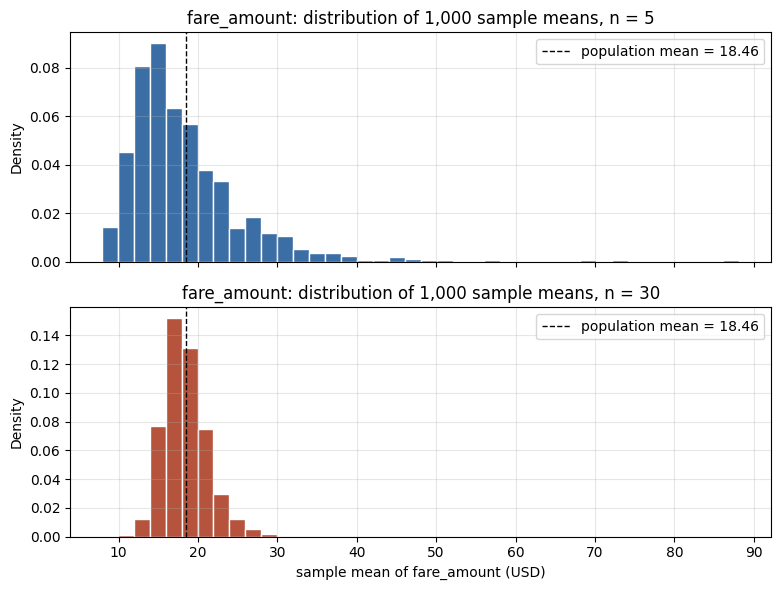

In [19]:
# Same experiment as for BA: 1,000 samples each of size 5 and 30, drawn with
# replacement from the cleaned fares; res_fare stores each sample's mean.
res_fare = sampling_experiment(fare)
pd.options.display.float_format = '{:.6g}'.format
# Show population variance both ways (ddof=0 vs ddof=1); with ~10,000 values they
# are nearly identical. Then the table: simulated variance of means vs sigma^2/n.
print('fare_amount (population var ddof=0: %.3f vs ddof=1: %.3f)' % (fare.var(ddof=0), fare.var(ddof=1))); display(summarize(fare, res_fare))
# Histograms of the means. Fares are strongly right-skewed, so n=5 means look
# skewed while n=30 look closer to a bell curve - the CLT needs a larger n for skewed data.
means_plot(fare, res_fare, 'fare_amount', 'USD')

**Larger samples give less variable means.** The variance of the sample means falls by roughly a factor of 6.6 going from n = 5 to n = 30 (54.8 -> 8.27), and the SD by a factor of about 2.6 (7.40 -> 2.88), close to the sqrt(6) ~ 2.4 expected from the 1/n rule.

**Agreement with the benchmark.** The simulated variances are close to (population variance with ddof=0) / n, with ratios of 0.97 (n = 5) and 0.88 (n = 30). The simulated means sit next to the population mean. The match is approximate, not exact: 1,000 Monte Carlo replications carry random error, and it is larger for heavy-tailed fares, where an occasional large fare appears in only a few samples (a ratio of 0.88 at n = 30 is plausible for such skewed data). The means of small samples (n = 5) are visibly skewed and more symmetric for n = 30.

**Why ddof=0 for the benchmark.** The retained values *are* the population here, and the exact variance of one uniformly drawn value is the population variance (divide by N, ddof=0). The B3 variance used ddof=1 because it estimates a variance from a sample. The two differ by the factor N/(N-1), tiny for N = 9,949.

### Reflection: what the simulation does and does not show

**Independence is built in, not demonstrated.** The experiment draws values independently and with replacement from a fixed list. That is why the variance of the sample mean follows (population variance) / n. Real years and real trips are not independent draws. Adjacent baseball seasons are strongly related (rules, ball, expansion and league-wide style change gradually), so BA has a temporal structure (early years sit higher, the 1890s are especially high) that a random draw from all years ignores. Taxi trips share drivers, vehicles, times of day, neighbourhoods and events (weather, holidays), and a random sample of one year cannot show independence among them. If observations are positively related, the real variance of a mean is larger than sigma^2 / n.

**Limits on generalizing.** The BA results describe these 154 annual league aggregates, equal-weighted, not players and not a pooled batting average, and the 2025 row is excluded because it is probably a partial season of unverified provenance. The taxi results describe 2024 green-taxi trips with valid timestamps and a positive fare, from a single random sample of 10,000 trips. They say nothing about other years, yellow or for-hire vehicles, or fare trends over time. Treating the cleaned data as an "empirical population" means the simulation only shows how sample means of *this* data vary; it is not a claim about a wider population.

**Averaging folds does not add precision.** Splitting a fixed dataset into equal-sized folds and averaging the fold means simply reproduces the overall mean. It gives one number, not a more precise estimate: the information available is still the same observations. Precision improves only with more independent information, which is what the larger sample size n = 30 stands for in the simulation.
